In [19]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [20]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    metrics_grid,
    plot_grid,
    plot_ball_behavior,
    plot_all_trajectories,
)
from sklearn.cluster import KMeans

from src.classify import classify_trajectories

In [21]:
model = "bruss"
ds_id = "param_sweep"
ds, output_dir = get_dataset(model, ds_id)
df = ds.df
df = expand_json_column(df, "original_point", "op", True)
df = expand_json_column(df, "initial_condition", "ic", True)
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]

In [22]:
df.value_counts("category")

category
INT    6206
DSS    4003
SS      472
OSC     119
Name: count, dtype: int64

<Axes: xlabel='ratio_b_a', ylabel='total_power'>

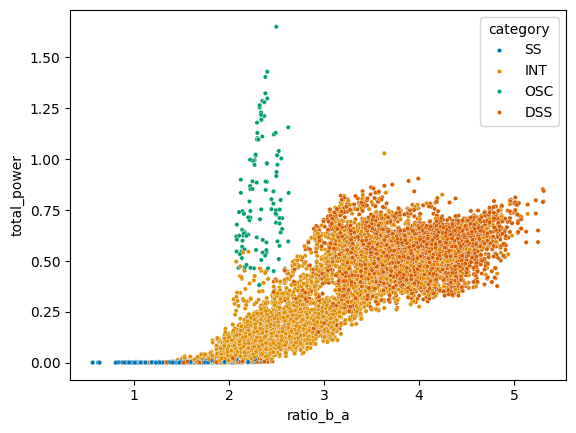

In [23]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="total_power", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)


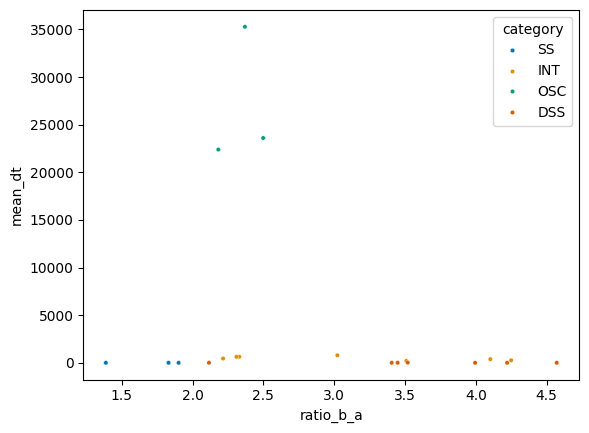

In [28]:
def sample_representative(df, proportions: dict, total_samples: int):
    features = ['A', 'B', 'Du', 'Dv']
    all_samples = []
    
    for category, prop in proportions.items():
        df_cat = df[df['category'] == category]
        k = min(int(total_samples * prop), len(df_cat))
        if k == 0:
            continue

        X = df_cat[features].to_numpy()
        km = KMeans(n_clusters=k, init='k-means++', n_init=5)
        km.fit(X)
        
        centers_df = df_cat.iloc[np.argmin(
            np.linalg.norm(X[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=0
        )]
        all_samples.append(centers_df)

    return pd.concat(all_samples).reset_index(drop=True)

proportions = {"SS": 0.15, "OSC": 0.15, "INT": 0.35, "DSS": 0.35}
df_sampled = sample_representative(df, proportions, 20)
sns.scatterplot(df_sampled, x="ratio_b_a", y="mean_dt", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
df_sampled.to_csv("../data/rep_samples.csv")